In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
#Cargar archivo csv desde s
df = pd.read_csv('Analisis GAC Full7agosto 2026(Analisis de Piso ).csv')

In [42]:
#Se hace quiere observar como esta el dataframe, para ver si hay datos nulos o vacios, y ver la estructura de los datos
df.head(5)

,Unnamed: 0,1170,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48,Unnamed: 49,Unnamed: 50
0,NaN,Leads Piso 2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,979,811,NaN,NaN,Factor minimo mejor vendedor,Factor minimo mejor vendedor,NaN,NaN
1,NaN,459,27,95,110,65,107,88,59,40,...,RAKING VENTAS,Dependencia de Piso,Historico de PDM,Historico de SDC,Conversion PDM,Conversion SDC,Factor PDM,Factor SDC,Raking PDM,Raking SDC
2,Asesor,feb,mar,abr,may,jun,jul,ago,sep,oct,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ABIGAIL,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23,0%,1,5,100%,0%,1.00,5.00,1,20
4,ALAN GONZALES,1,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,...,6,61%,59,40,31%,2%,3.28,2.22,7,10


Limpieza de la base de datos

In [43]:
#Cargar la base sin tomar la primera fila como encabezado.
df = pd.read_csv(
    'Analisis GAC Full7agosto 2026(Analisis de Piso ).csv',
    header=None,
    encoding="utf-8-sig",
    dtype=str
)

print("Dimensiones originales:", df.shape)
df.head()

Dimensiones originales: (44, 51)


,0,1,2,3,4,5,6,7,8,9,...,41,42,43,44,45,46,47,48,49,50
0,NaN,1170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,Leads Piso 2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,979,811,NaN,NaN,Factor minimo mejor vendedor,Factor minimo mejor vendedor,NaN,NaN
2,NaN,459,27,95,110,65,107,88,59,40,...,RAKING VENTAS,Dependencia de Piso,Historico de PDM,Historico de SDC,Conversion PDM,Conversion SDC,Factor PDM,Factor SDC,Raking PDM,Raking SDC
3,Asesor,feb,mar,abr,may,jun,jul,ago,sep,oct,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ABIGAIL,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23,0%,1,5,100%,0%,1.00,5.00,1,20


In [44]:
#Se van a reconstruir los encabezados, por lo tanto se eleminan los anteriores.
# Los datos reales de los asesores comienzan en la fila 4
df = df.iloc[4:].copy()

# Reiniciar el índice
df.reset_index(drop=True, inplace=True)

In [45]:
#Asignar nombres claros a cada una de las columnas.
df.columns = [
    "Asesor",

    # Leads de 2024
    "Leads_2024_Feb",
    "Leads_2024_Mar",
    "Leads_2024_Abr",
    "Leads_2024_May",
    "Leads_2024_Jun",
    "Leads_2024_Jul",
    "Leads_2024_Ago",
    "Leads_2024_Sep",
    "Leads_2024_Oct",
    "Leads_2024_Nov",
    "Leads_2024_Dic",

    # Leads de 2025
    "Leads_2025_Ene",
    "Leads_2025_Feb",
    "Leads_2025_Mar",
    "Leads_2025_Abr",

    # Totales y raking de leads
    "Total_Leads",
    "Total_Leads_Ajustado",
    "Raking_Leads",
    "Raking_Leads_Ajustado",

    # Ventas de piso de 2024
    "Ventas_2024_Feb",
    "Ventas_2024_Mar",
    "Ventas_2024_Abr",
    "Ventas_2024_May",
    "Ventas_2024_Jun",
    "Ventas_2024_Jul",
    "Ventas_2024_Ago",
    "Ventas_2024_Sep",
    "Ventas_2024_Oct",
    "Ventas_2024_Nov",
    "Ventas_2024_Dic",

    # Ventas de piso de 2025
    "Ventas_2025_Ene",
    "Ventas_2025_Feb",
    "Ventas_2025_Mar",
    "Ventas_2025_Abr",
    "Ventas_2025_May",
    "Ventas_2025_Jun",

    # Indicadores generales
    "Leads_Promedio_Mes",
    "Total_Ventas_Piso",
    "Factor",
    "Total_Ventas_Historicas",
    "Raking_Ventas",
    "Dependencia_Piso",
    "Historico_PDM",
    "Historico_SDC",
    "Conversion_PDM",
    "Conversion_SDC",
    "Factor_PDM",
    "Factor_SDC",
    "Raking_PDM",
    "Raking_SDC"
]


In [46]:
#Corroborar
df.head()

,Asesor,Leads_2024_Feb,Leads_2024_Mar,Leads_2024_Abr,Leads_2024_May,Leads_2024_Jun,Leads_2024_Jul,Leads_2024_Ago,Leads_2024_Sep,Leads_2024_Oct,...,Raking_Ventas,Dependencia_Piso,Historico_PDM,Historico_SDC,Conversion_PDM,Conversion_SDC,Factor_PDM,Factor_SDC,Raking_PDM,Raking_SDC
0,ABIGAIL,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23,0%,1,5,100%,0%,1.00,5.00,1,20
1,ALAN GONZALES,1,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,...,6,61%,59,40,31%,2%,3.28,2.22,7,10
2,ALICIA LEDESMA,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0%,1,1,0%,0%,0.00,0.00,NaN,NaN
3,AURELIO FELIPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,6,...,11,38%,28,31,29%,1%,3.50,3.88,9,18
4,CARLOS ALBERTO NIETO,NaN,NaN,NaN,2,NaN,NaN,2,8,4,...,8,60%,64,30,23%,2%,4.27,2.00,13,7


In [47]:
#limpiar espacios y características invisibles como espacios
# Reemplazar espacios especiales, saltos de línea y tabulaciones
df = df.replace(
    {
        r"\u00a0": "",
        r"\n": " ",
        r"\r": " ",
        r"\t": " "
    },
    regex=True
)

# Eliminar espacios al inicio y al final de todas las columnas
for columna in df.columns:
    df[columna] = df[columna].str.strip()

# Estandarizar los nombres de los asesores
df["Asesor"] = (
    df["Asesor"]
    .str.upper()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [48]:
#Reemplazar valores que representan datos faltantes.
valores_faltantes = [
    "",
    " ",
    "-",
    "–",
    "—",
    "#DIV/0!",
    "#N/A",
    "N/A",
    "NA",
    "NULL",
    "NONE"
]

df.replace(valores_faltantes, np.nan, inplace=True)

,Asesor,Leads_2024_Feb,Leads_2024_Mar,Leads_2024_Abr,Leads_2024_May,Leads_2024_Jun,Leads_2024_Jul,Leads_2024_Ago,Leads_2024_Sep,Leads_2024_Oct,...,Raking_Ventas,Dependencia_Piso,Historico_PDM,Historico_SDC,Conversion_PDM,Conversion_SDC,Factor_PDM,Factor_SDC,Raking_PDM,Raking_SDC
0,ABIGAIL,23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,23,0%,1,5,100%,0%,1.00,5.00,1,20
1,ALAN GONZALES,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6,61%,59,40,31%,2%,3.28,2.22,7,10
2,ALICIA LEDESMA,NaN,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,...,0,0%,1,1,0%,0%,0.00,0.00,NaN,NaN
3,AURELIO FELIPE,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,6,...,11,38%,28,31,29%,1%,3.50,3.88,9,18
4,CARLOS ALBERTO NIETO,NaN,NaN,NaN,2,NaN,NaN,2,8,4,...,8,60%,64,30,23%,2%,4.27,2.00,13,7
5,CARLOS TEXIS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,...,17,25%,21,26,19%,1%,5.25,6.50,18,23
6,CARLOS MANUEL CARMONA,18,10,27,34,11,3,NaN,NaN,NaN,...,0,0%,54,8,0%,0%,0.00,0.00,NaN,NaN
7,CINTYA,NaN,NaN,NaN,NaN,1,NaN,NaN,NaN,NaN,...,0,0%,3,5,0%,0%,0.00,0.00,NaN,NaN
8,CLAUDIA GALVAN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,19,0%,25,22,8%,0%,12.50,11.00,22,26
9,CASA,1,NaN,3,3,2,NaN,NaN,NaN,NaN,...,4,10%,20,32,105%,0%,0.95,1.52,NaN,3


In [49]:
#Convertir porcentajes
columnas_porcentaje = [
    "Factor",
    "Dependencia_Piso",
    "Conversion_PDM",
    "Conversion_SDC"
]

for columna in columnas_porcentaje:
    df[columna] = (
        df[columna]
        .str.replace("%", "", regex=False)
        .str.replace(",", ".", regex=False)
    )

    df[columna] = pd.to_numeric(
        df[columna],
        errors="coerce"
    ) / 100

In [50]:
#convertir las demás columnas a numéricas
columnas_numericas = [
    columna for columna in df.columns
    if columna != "Asesor" and columna not in columnas_porcentaje
]

for columna in columnas_numericas:
    df[columna] = (
        df[columna]
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
    )

    df[columna] = pd.to_numeric(
        df[columna],
        errors="coerce"
    )

In [51]:
#Colocar cero en los meses sin leads o ventas
columnas_mensuales = [
    columna for columna in df.columns
    if columna.startswith("Leads_2024_")
    or columna.startswith("Leads_2025_")
    or columna.startswith("Ventas_2024_")
    or columna.startswith("Ventas_2025_")
]

df[columnas_mensuales] = df[columnas_mensuales].fillna(0)


In [52]:
#Eliminar cuentas que no correspenden a asesores reales
cuentas_no_asesores = [
    "CASA",
    "DEMO VENDEDOR",
    "SYS_COMPETITION",
    "USUARIO DE BDC Y CASA"
]

df = df[~df["Asesor"].isin(cuentas_no_asesores)].copy()

# Eliminar filas que no tengan nombre de asesor
df.dropna(subset=["Asesor"], inplace=True)

# Reiniciar el índice
df.reset_index(drop=True, inplace=True)

In [53]:
#Revisión final de los datos
print("Dimensiones de la base limpia:", df.shape)

print("\nTipos de variables:")
print(df.dtypes)

print("\nValores faltantes por columna:")
print(df.isna().sum().sort_values(ascending=False))

print("\nFilas completamente duplicadas:")
print(df.duplicated().sum())

print("\nNombres de asesores:")
print(df["Asesor"].sort_values().tolist())

df.head()

Dimensiones de la base limpia: (36, 51)

Tipos de variables:
Asesor                         str
Leads_2024_Feb             float64
Leads_2024_Mar             float64
Leads_2024_Abr             float64
Leads_2024_May             float64
Leads_2024_Jun             float64
Leads_2024_Jul             float64
Leads_2024_Ago             float64
Leads_2024_Sep             float64
Leads_2024_Oct             float64
Leads_2024_Nov             float64
Leads_2024_Dic             float64
Leads_2025_Ene             float64
Leads_2025_Feb             float64
Leads_2025_Mar             float64
Leads_2025_Abr             float64
Total_Leads                  int64
Total_Leads_Ajustado         int64
Raking_Leads                 int64
Raking_Leads_Ajustado        int64
Ventas_2024_Feb            float64
Ventas_2024_Mar            float64
Ventas_2024_Abr            float64
Ventas_2024_May            float64
Ventas_2024_Jun            float64
Ventas_2024_Jul            float64
Ventas_2024_Ago            fl

,Asesor,Leads_2024_Feb,Leads_2024_Mar,Leads_2024_Abr,Leads_2024_May,Leads_2024_Jun,Leads_2024_Jul,Leads_2024_Ago,Leads_2024_Sep,Leads_2024_Oct,...,Raking_Ventas,Dependencia_Piso,Historico_PDM,Historico_SDC,Conversion_PDM,Conversion_SDC,Factor_PDM,Factor_SDC,Raking_PDM,Raking_SDC
0,ABIGAIL,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.0,0.00,1,5.0,1.00,0.00,1.00,5.00,1.0,20.0
1,ALAN GONZALES,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,0.61,59,40.0,0.31,0.02,3.28,2.22,7.0,10.0
2,ALICIA LEDESMA,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00,1,1.0,0.00,0.00,0.00,0.00,NaN,NaN
3,AURELIO FELIPE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,...,11.0,0.38,28,31.0,0.29,0.01,3.50,3.88,9.0,18.0
4,CARLOS ALBERTO NIETO,0.0,0.0,0.0,2.0,0.0,0.0,2.0,8.0,4.0,...,8.0,0.60,64,30.0,0.23,0.02,4.27,2.00,13.0,7.0


In [54]:
#Eliminar datos duplicados exactos
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)


In [55]:
df.head()

,Asesor,Leads_2024_Feb,Leads_2024_Mar,Leads_2024_Abr,Leads_2024_May,Leads_2024_Jun,Leads_2024_Jul,Leads_2024_Ago,Leads_2024_Sep,Leads_2024_Oct,...,Raking_Ventas,Dependencia_Piso,Historico_PDM,Historico_SDC,Conversion_PDM,Conversion_SDC,Factor_PDM,Factor_SDC,Raking_PDM,Raking_SDC
0,ABIGAIL,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.0,0.00,1,5.0,1.00,0.00,1.00,5.00,1.0,20.0
1,ALAN GONZALES,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,0.61,59,40.0,0.31,0.02,3.28,2.22,7.0,10.0
2,ALICIA LEDESMA,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00,1,1.0,0.00,0.00,0.00,0.00,NaN,NaN
3,AURELIO FELIPE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,6.0,...,11.0,0.38,28,31.0,0.29,0.01,3.50,3.88,9.0,18.0
4,CARLOS ALBERTO NIETO,0.0,0.0,0.0,2.0,0.0,0.0,2.0,8.0,4.0,...,8.0,0.60,64,30.0,0.23,0.02,4.27,2.00,13.0,7.0


Regresion lineal

¿En qué medida la cantidad de leads asignados a un asesor se relaciona con sus ventas de piso?

-Variable independiente X: Total_Leads_Ajustado
-Variable dependiente y: Total_Ventas_Piso

In [56]:
# Crear un DataFrame únicamente con las variables de la regresión
df_regresion = df[
    ["Total_Leads_Ajustado", "Total_Ventas_Piso"]
].copy()

# Eliminar solamente las observaciones sin datos en estas variables
df_regresion.dropna(inplace=True)

# Variable independiente: número de leads
Vars_Indep = df_regresion[["Total_Leads_Ajustado"]]

# Variable dependiente: ventas realizadas
Var_Dep = df_regresion["Total_Ventas_Piso"]

df_regresion.head()

,Total_Leads_Ajustado,Total_Ventas_Piso
0,0,0
1,61,11
2,0,0
3,33,3
4,55,9


<Axes: xlabel='Total_Leads_Ajustado', ylabel='Total_Ventas_Piso'>

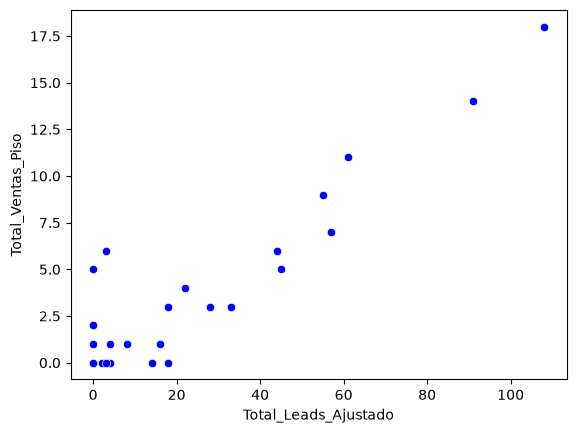

In [57]:
#Imprimimos el scatter plot entre la variable dependiente e independiente
#para observar el comportamiento en su dispersión 
from turtle import color
sns.scatterplot(x='Total_Leads_Ajustado', y='Total_Ventas_Piso', color="blue", data=df_regresion)

In [58]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [59]:
#Se define model como la función de regresión lineal
from sklearn.linear_model import LinearRegression
model= LinearRegression()

In [60]:
#Ajustamos el modelo con las variables antes declaradas
model.fit(X=Vars_Indep, y=Var_Dep)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.15]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Total_Leads_Ajustado']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.2104
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [61]:
#Verificamos los coeficientes obtenidos para el modelo ajustado
model.__dict__

{'fit_intercept': True,
 'copy_X': True,
 'tol': 1e-06,
 'n_jobs': None,
 'positive': False,
 'feature_names_in_': array(['Total_Leads_Ajustado'], dtype=object),
 'n_features_in_': 1,
 'coef_': array([0.14685326]),
 'rank_': np.int64(1),
 'singular_': array([161.30810753]),
 'intercept_': np.float64(0.21037096028635816)}

In [62]:
#Evaluamos la eficiencia del modelo obtenido por medio del coeficiente R Determinación
model.score(Vars_Indep,Var_Dep)

0.8515186305682253

In [63]:
#Predecimos los valores de total de accidentes a partir de la variable "Ventas"
y_pred= model.predict(X=df[['Total_Leads_Ajustado']])
y_pred

array([ 0.21037096,  9.16841975,  0.21037096,  5.0565285 ,  8.2873002 ,
        0.797784  ,  0.65093074,  0.21037096,  0.65093074,  6.81876761,
        0.21037096,  0.21037096,  0.797784  ,  8.58100671,  0.21037096,
        1.38519703,  0.50407748,  0.21037096,  0.21037096,  6.67191435,
        0.797784  ,  0.21037096,  0.50407748,  0.21037096,  4.32226221,
        3.44114265, 16.07052291,  2.5600231 ,  2.85372962,  0.21037096,
        2.26631658,  0.21037096,  0.21037096, 13.57401751,  0.65093074,
        2.85372962])

In [64]:
#Insertamos la columna de predicciones en el DataFrame
df.insert(0, 'Predicciones', y_pred)
df

,Predicciones,Asesor,Leads_2024_Feb,Leads_2024_Mar,Leads_2024_Abr,Leads_2024_May,Leads_2024_Jun,Leads_2024_Jul,Leads_2024_Ago,Leads_2024_Sep,...,Raking_Ventas,Dependencia_Piso,Historico_PDM,Historico_SDC,Conversion_PDM,Conversion_SDC,Factor_PDM,Factor_SDC,Raking_PDM,Raking_SDC
0,0.210371,ABIGAIL,23.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,23.0,0.00,1,5.0,1.00,0.00,1.00,5.00,1.0,20.0
1,9.168420,ALAN GONZALES,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.0,0.61,59,40.0,0.31,0.02,3.28,2.22,7.0,10.0
2,0.210371,ALICIA LEDESMA,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.00,1,1.0,0.00,0.00,0.00,0.00,NaN,NaN
3,5.056529,AURELIO FELIPE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,11.0,0.38,28,31.0,0.29,0.01,3.50,3.88,9.0,18.0
4,8.287300,CARLOS ALBERTO NIETO,0.0,0.0,0.0,2.0,0.0,0.0,2.0,8.0,...,8.0,0.60,64,30.0,0.23,0.02,4.27,2.00,13.0,7.0
5,0.797784,CARLOS TEXIS,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,17.0,0.25,21,26.0,0.19,0.01,5.25,6.50,18.0,23.0
6,0.650931,CARLOS MANUEL CARMONA,18.0,10.0,27.0,34.0,11.0,3.0,0.0,0.0,...,0.0,0.00,54,8.0,0.00,0.00,0.00,0.00,NaN,NaN
7,0.210371,CINTYA,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.00,3,5.0,0.00,0.00,0.00,0.00,NaN,NaN
8,0.650931,CLAUDIA GALVAN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,19.0,0.00,25,22.0,0.08,0.00,12.50,11.00,22.0,26.0
9,6.818768,DANIEL DE LEON CANDIA,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,9.0,0.42,36,25.0,0.33,0.02,3.00,2.08,6.0,9.0


<Axes: xlabel='Total_Leads_Ajustado', ylabel='Total_Ventas_Piso'>

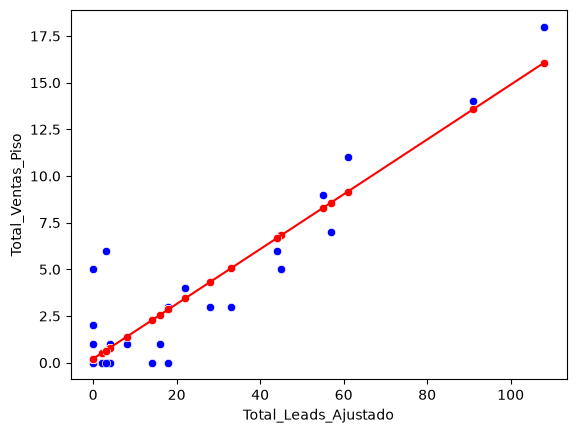

In [65]:
#Visualizamos la gráfica comparativa entre el total real y el total predecido

sns.scatterplot(x='Total_Leads_Ajustado', y='Total_Ventas_Piso', color="blue", data=df)
sns.scatterplot(x='Total_Leads_Ajustado', y='Predicciones', color="red", data=df)
sns.lineplot(x='Total_Leads_Ajustado', y='Predicciones', color="red", data=df)

In [66]:
#Corroboramos cual es el coeficiente de Determinación de nuestro modelo
coef_Deter=model.score(X=Vars_Indep, y=Var_Dep)
coef_Deter

0.8515186305682253

In [67]:
#Corroboramos cual es el coeficiente de Correlación de nuestro modelo
coef_Correl=np.sqrt(coef_Deter)
coef_Correl

np.float64(0.9227776712557718)

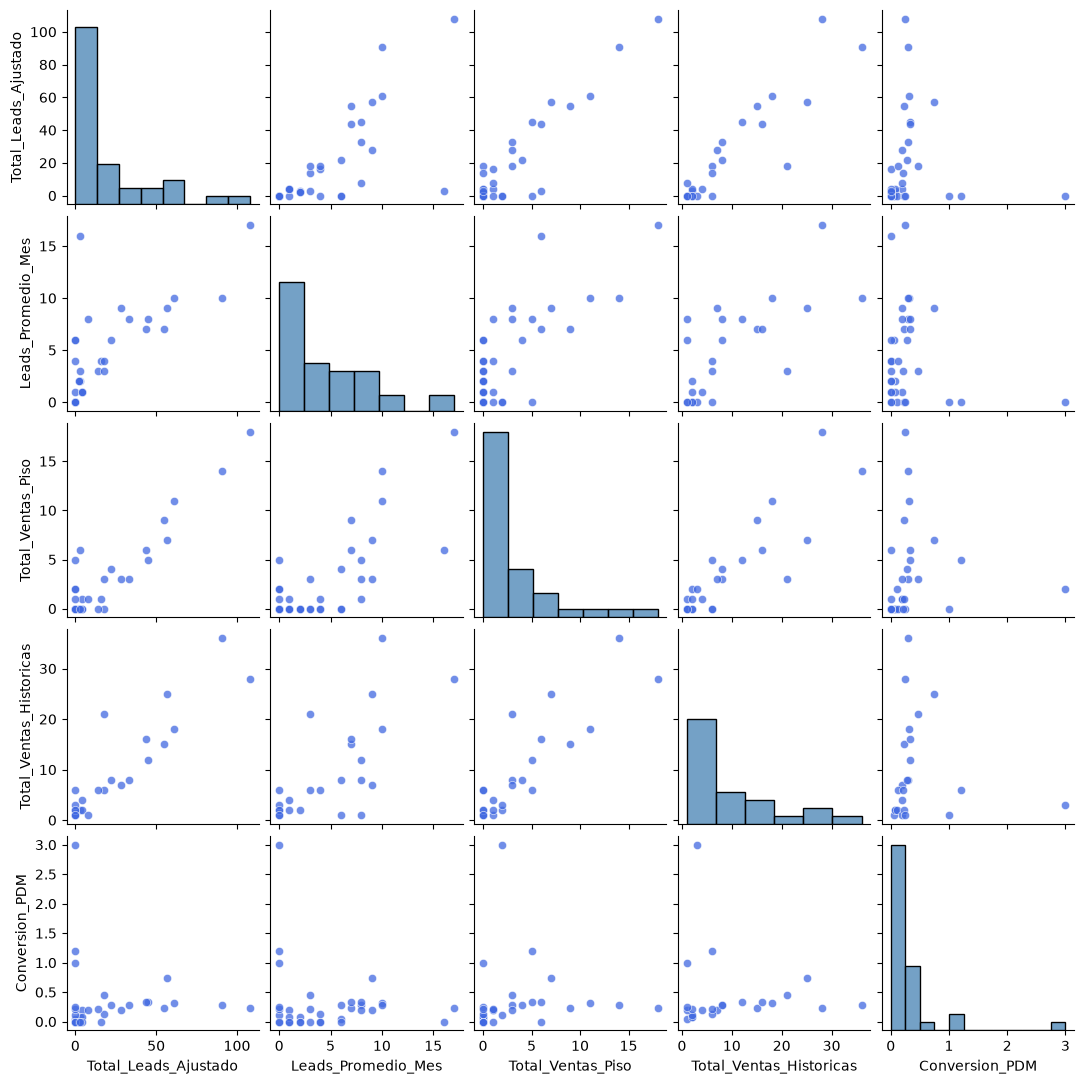

In [68]:
#Se hace un nuevo tipo de código ya que el enseñado en el curso marcó error
variables_grafica = [
    "Total_Leads_Ajustado",
    "Leads_Promedio_Mes",
    "Total_Ventas_Piso",
    "Total_Ventas_Historicas",
    "Conversion_PDM"
]

df_pairplot = df[variables_grafica].copy()

sns.pairplot(
    df_pairplot,
    diag_kind="hist",
    height=2.2,
    corner=False,
    plot_kws={
        "color": "royalblue",
        "s": 35,
        "alpha": 0.75
    },
    diag_kws={
        "color": "steelblue",
        "edgecolor": "black"
    }
)

plt.show()

In [70]:
# Variables numéricas relevantes para el análisis
variables_correlacion = [
    "Total_Leads",
    "Total_Leads_Ajustado",
    "Leads_Promedio_Mes",
    "Total_Ventas_Piso",
    "Total_Ventas_Historicas",
    "Conversion_PDM"
]

# Crear DataFrame con las variables seleccionadas
df_correlacion = df[variables_correlacion].copy()

# Calcular las correlaciones
Corr_Factors = df_correlacion.corr()

Corr_Factors

,Total_Leads,Total_Leads_Ajustado,Leads_Promedio_Mes,Total_Ventas_Piso,Total_Ventas_Historicas,Conversion_PDM
Total_Leads,1.000000,0.658070,0.645691,0.741479,0.680785,-0.095050
Total_Leads_Ajustado,0.658070,1.000000,0.731347,0.922778,0.905321,0.003536
Leads_Promedio_Mes,0.645691,0.731347,1.000000,0.748547,0.705860,-0.157629
Total_Ventas_Piso,0.741479,0.922778,0.748547,1.000000,0.870418,0.112378
Total_Ventas_Historicas,0.680785,0.905321,0.705860,0.870418,1.000000,-0.067075
Conversion_PDM,-0.095050,0.003536,-0.157629,0.112378,-0.067075,1.000000


In [71]:
#Encontramos el valor absoluto de todas las correlaciones entre las variables 
Corr_Factors1= abs(Corr_Factors)
Corr_Factors1

,Total_Leads,Total_Leads_Ajustado,Leads_Promedio_Mes,Total_Ventas_Piso,Total_Ventas_Historicas,Conversion_PDM
Total_Leads,1.000000,0.658070,0.645691,0.741479,0.680785,0.095050
Total_Leads_Ajustado,0.658070,1.000000,0.731347,0.922778,0.905321,0.003536
Leads_Promedio_Mes,0.645691,0.731347,1.000000,0.748547,0.705860,0.157629
Total_Ventas_Piso,0.741479,0.922778,0.748547,1.000000,0.870418,0.112378
Total_Ventas_Historicas,0.680785,0.905321,0.705860,0.870418,1.000000,0.067075
Conversion_PDM,0.095050,0.003536,0.157629,0.112378,0.067075,1.000000


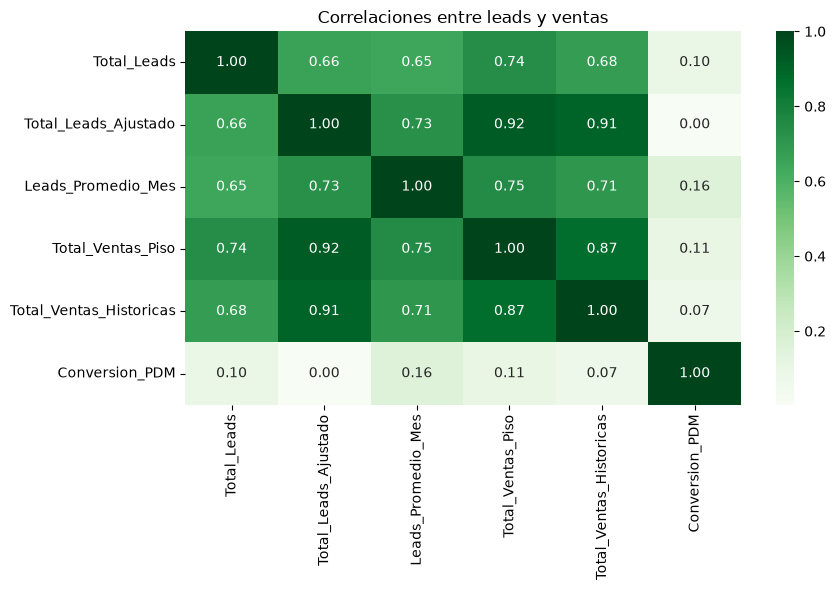

In [ ]:
#hetmap de correlaciones entre las variables

plt.figure(figsize=(9, 6))

sns.heatmap(
    Corr_Factors1,
    cmap="Greens",
    annot=True,
    fmt=".2f"
)

plt.title("Correlaciones entre leads y ventas")
plt.tight_layout()
plt.show()